In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_watch_history = pd.read_csv(r"C:\Users\Bhagyashri\Downloads\ff5a102e4361911d42cef9e21cda23d0\watch_history.csv")

In [3]:
df_watch_history.head(5)

,watch_id,subscriber_id,title_id,watch_date,device,region,content_duration_min,watch_duration_min,completion_pct,completed
0,1,SUB107630,TTL205207,2024-01-01,Smart TV,East Asia,888,826.7,93.1,True
1,2,SUB114773,TTL204889,2025-10-18,Mobile,South Asia,2340,1866.4,79.8,False
2,3,SUB106013,TTL206882,2026-04-26,Mobile,Latin America,656,75.0,11.4,False
3,4,SUB100939,TTL208849,2026-03-09,Mobile,North America,500,493.2,98.6,True
4,5,SUB107223,TTL202529,2023-12-27,Tablet,North America,141,94.6,67.1,False


In [4]:
df_watch_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650000 entries, 0 to 649999
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   watch_id              650000 non-null  int64  
 1   subscriber_id         650000 non-null  object 
 2   title_id              650000 non-null  object 
 3   watch_date            650000 non-null  object 
 4   device                650000 non-null  object 
 5   region                650000 non-null  object 
 6   content_duration_min  650000 non-null  int64  
 7   watch_duration_min    650000 non-null  float64
 8   completion_pct        650000 non-null  float64
 9   completed             650000 non-null  bool   
dtypes: bool(1), float64(2), int64(2), object(5)
memory usage: 45.3+ MB


In [5]:
df_watch_history['watch_date'] = pd.to_datetime(df_watch_history['watch_date'])

### **•	Monthly viewing volume — a bar or line chart showing number of sessions per month across the timeline. Highlight the busiest months.**

In [6]:
df_watch_history['month'] = df_watch_history['watch_date'].dt.to_period('M')

In [7]:
monthly_sessions = df_watch_history['month'].value_counts().sort_index()

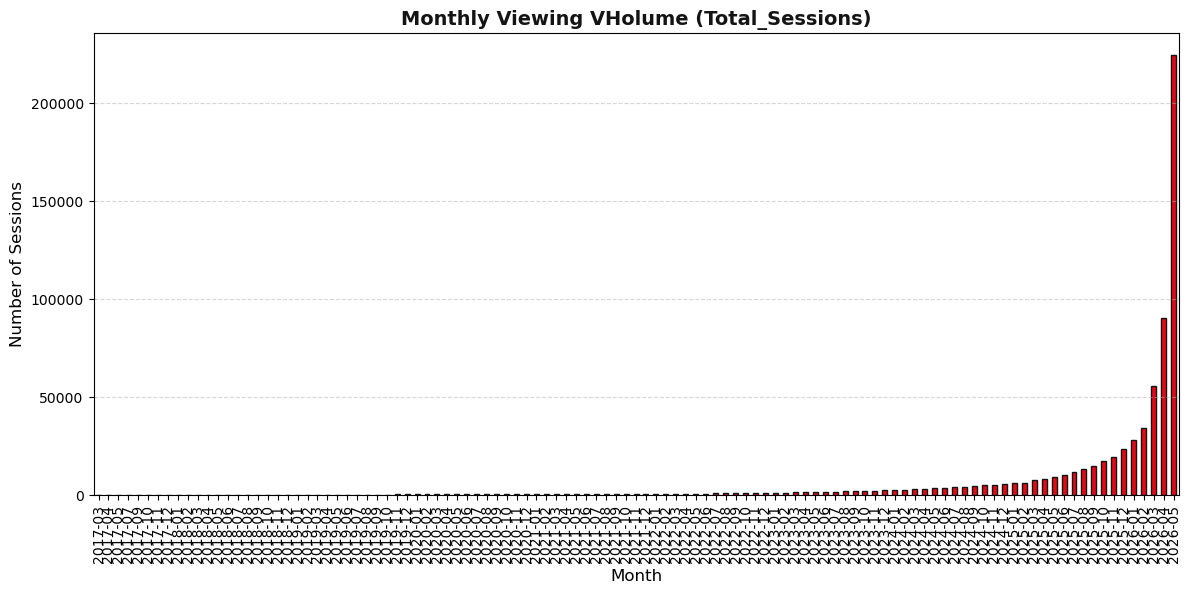

In [8]:
plt.figure(figsize=(14,6))
monthly_sessions.plot(kind='bar',color='#E50914',edgecolor='#141414')
plt.title('Monthly Viewing VHolume (Total_Sessions)',fontsize=14, fontweight='bold',color='#141414')
plt.xlabel('Month',fontsize=12)
plt.ylabel('Number of Sessions',fontsize=12)
plt.xticks(rotation=90)
plt.grid(axis='y',linestyle='--',alpha=0.5)
plt.savefig('Phase2_Chart1_Bhagyashri.png',dpi=300,bbox_inches='tight')
plt.show()

### **•	Monthly watch hours trend — same as above but using watch_duration_min (converted to hours). Compare year-over-year.**

In [9]:
df_watch_history['Hour'] = df_watch_history['watch_duration_min']/60

In [10]:
Monthly_Watch_Hours_Trend = df_watch_history.groupby('month')['Hour'].sum().sort_index()

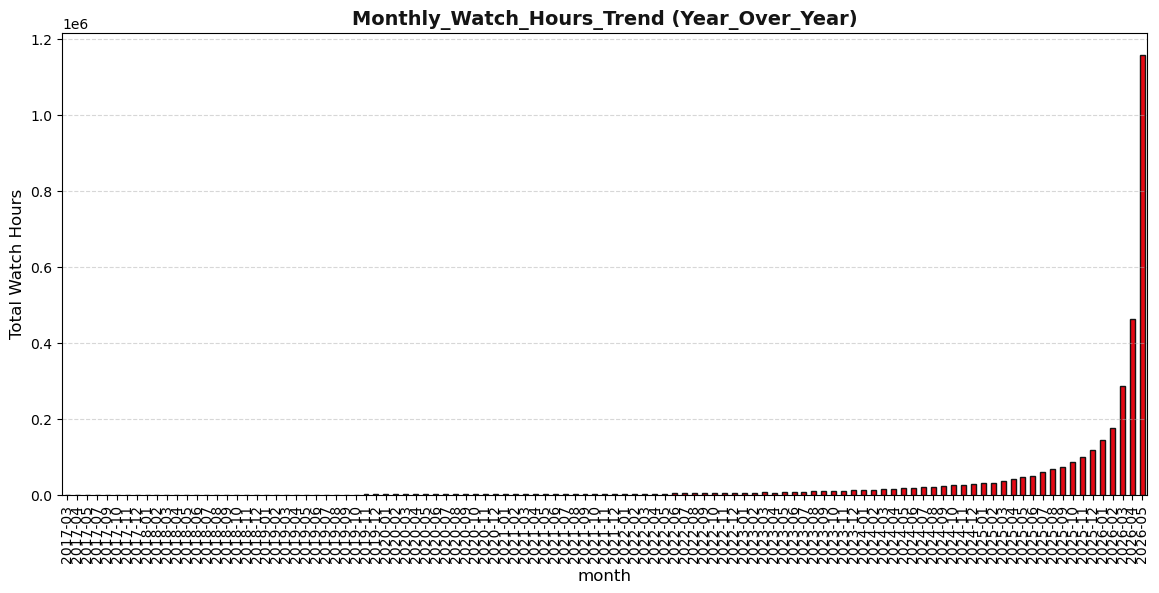

In [11]:
plt.figure(figsize=(14,6))
Monthly_Watch_Hours_Trend.plot(kind='bar',color='#E50914',edgecolor='#141414')
plt.title('Monthly_Watch_Hours_Trend (Year_Over_Year)',fontsize=14, fontweight='bold',color='#141414')
plt.xlabel('month',fontsize=12)
plt.ylabel('Total Watch Hours',fontsize=12)
plt.xticks(rotation=90)
plt.grid(axis='y',linestyle='--',alpha=0.5)
plt.savefig('Phase2_Chart2_Bhagyashri.png',dpi=300,bbox_inches='tight')
plt.show()

### **•	Genre-wise watch-hours share — a pie or horizontal bar chart. Which genre earns the most watch time?**

In [12]:
df_titles = pd.read_csv(r"C:\Users\Bhagyashri\Downloads\ff5a102e4361911d42cef9e21cda23d0\titles.csv")

In [13]:
merge_dataset = pd.merge(df_watch_history, df_titles, on='title_id', how='inner')

In [14]:
genre_watch_hours = merge_dataset.groupby('primary_genre')['Hour'].sum().sort_index()

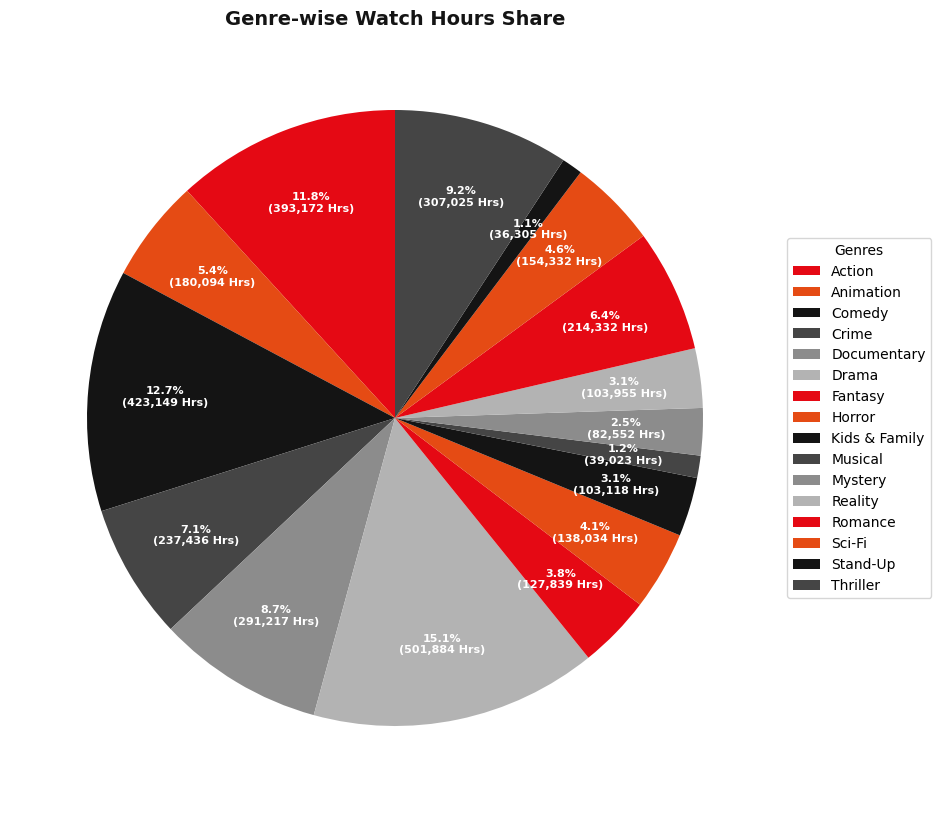

In [15]:
plt.figure(figsize=(12, 10))
streamflix_colors = ['#E50914', '#E54B14', '#141414', '#454545', '#8C8C8C', '#B3B3B3']

def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n({val:,} Hrs)'
    return my_autopct
genre_watch_hours.plot(
    kind='pie', 
    labels=None, 
    autopct=make_autopct(genre_watch_hours), 
    startangle=90, 
    colors=streamflix_colors, 
    fontsize=8,
    pctdistance=0.75,
    textprops={'color': 'white', 'weight': 'bold'}
)
plt.title('Genre-wise Watch Hours Share', fontsize=14, fontweight='bold', color='#141414')
plt.ylabel('')
plt.legend(
    labels=genre_watch_hours.index, 
    loc="center left", 
    bbox_to_anchor=(1, 0, 0.5, 1), 
    fontsize=10,
    title="Genres"
)

plt.savefig('Phase2_Chart3_Clean_Bhagyashri.png', dpi=300, bbox_inches='tight')
plt.show()

### **•	Content type split — a donut chart showing the share of hours for Movies vs. TV Shows.**

In [16]:
content_watch_hours = merge_dataset.groupby('type')['Hour'].sum()

In [17]:
print(content_watch_hours)

type
Movie      4.508588e+05
TV Show    2.882609e+06
Name: Hour, dtype: float64


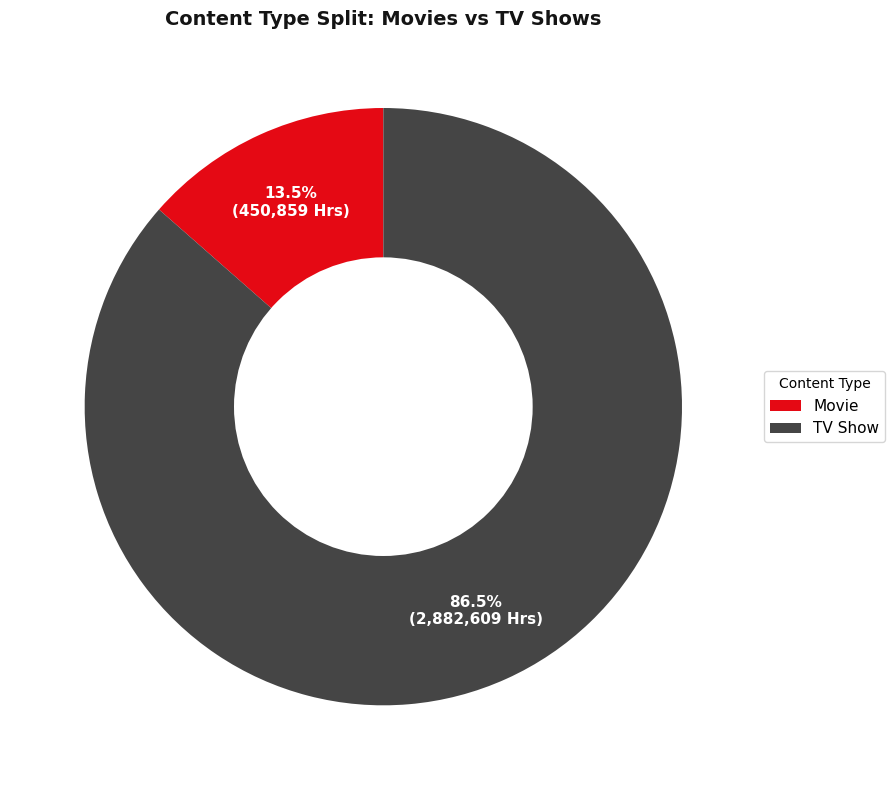

In [18]:
plt.figure(figsize=(10, 8)) 
content_colors = ['#E50914', '#454545']

def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n({val:,} Hrs)'
    return my_autopct


patches, texts, autotexts = plt.pie(
    content_watch_hours, 
    labels=None, 
    autopct=make_autopct(content_watch_hours), 
    startangle=90, 
    colors=content_colors,
    pctdistance=0.75,
    textprops={'fontsize': 11, 'weight': 'bold'}
)

for autotext in autotexts:
    autotext.set_color('white')

centre_circle = plt.Circle((0,0), 0.50, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Content Type Split: Movies vs TV Shows', fontsize=14, fontweight='bold', color='#141414')

plt.legend(
    labels=content_watch_hours.index, 
    loc="center left", 
    bbox_to_anchor=(1, 0.5), 
    fontsize=11,
    title="Content Type"
)

plt.tight_layout()
plt.savefig('Phase2_Chart4_Donut_Final_Bhagyashri.png', dpi=300, bbox_inches='tight')
plt.show()

### **•	Top 10 countries by watch hours — a horizontal bar chart.**

In [19]:
country_watch_hours = merge_dataset.groupby('country')['Hour'].sum().sort_values(ascending=False)

In [20]:
top_10_countries = country_watch_hours.head(10)

In [21]:
top_10_countries =top_10_countries.sort_values(ascending=True)
print(top_10_countries)

country
Canada            107072.951667
France            115011.761667
Spain             143656.396667
Mexico            157176.858333
Brazil            176353.601667
Japan             207130.865000
South Korea       223476.403333
United Kingdom    282946.390000
India             464337.756667
United States     822684.680000
Name: Hour, dtype: float64


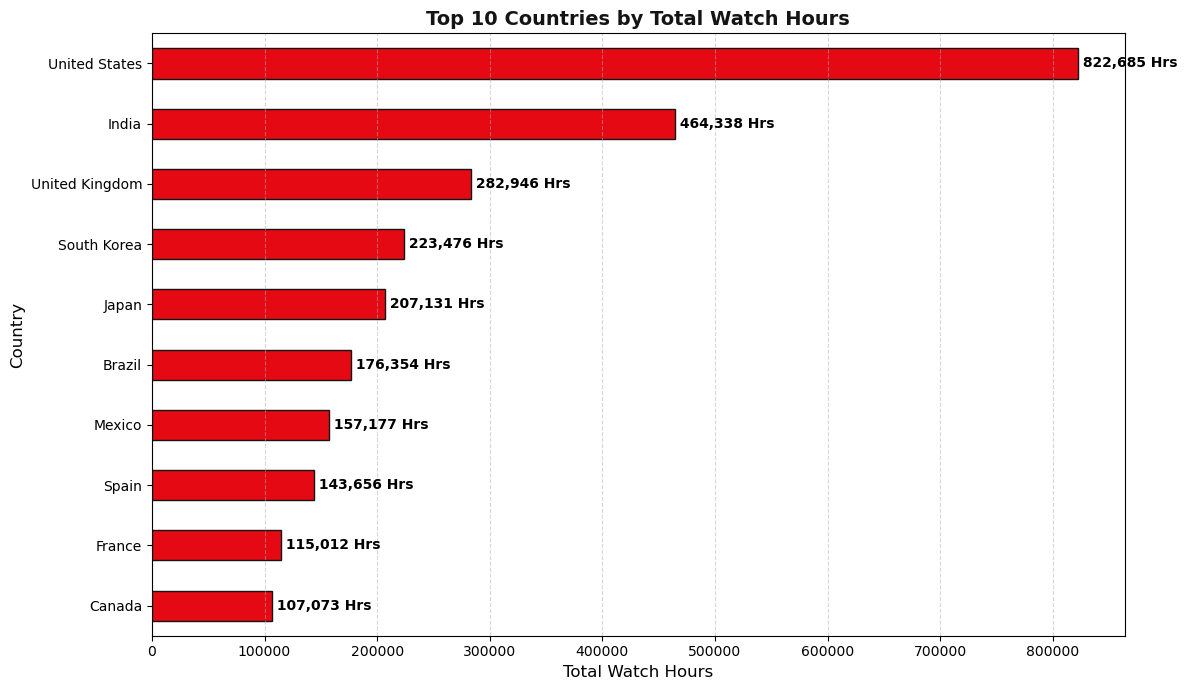

In [22]:
plt.figure(figsize=(12, 7))
streamflix_red = '#E50914'

top_10_countries.plot(kind='barh', color=streamflix_red, edgecolor='#141414')

plt.title('Top 10 Countries by Total Watch Hours', fontsize=14, fontweight='bold', color='#141414')
plt.xlabel('Total Watch Hours', fontsize=12)
plt.ylabel('Country', fontsize=12)

for index, value in enumerate(top_10_countries):
    rounded_value = int(round(value))
    plt.text(value, index, f' {rounded_value:,} Hrs', va='center', fontsize=10, fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('Phase2_Chart5_TopCountries_Final.png', dpi=300, bbox_inches='tight')
plt.show()

### **•	Subscriber plan distribution — a pie chart. How many Basic vs. Standard vs. Premium subscribers?**

In [23]:
df_subscribers = pd.read_csv(r"C:\Users\Bhagyashri\Downloads\ff5a102e4361911d42cef9e21cda23d0\subscribers.csv")

In [24]:
merge_dataset1 = pd.merge(df_watch_history,df_subscribers,on='subscriber_id',how='inner')

In [25]:
subscriber_counts = df_subscribers['plan_type'].value_counts()
print("Total Subscribers by Plan Type:")
print(subscriber_counts)

Total Subscribers by Plan Type:
plan_type
Standard          6100
Basic with Ads    4458
Premium           4442
Name: count, dtype: int64


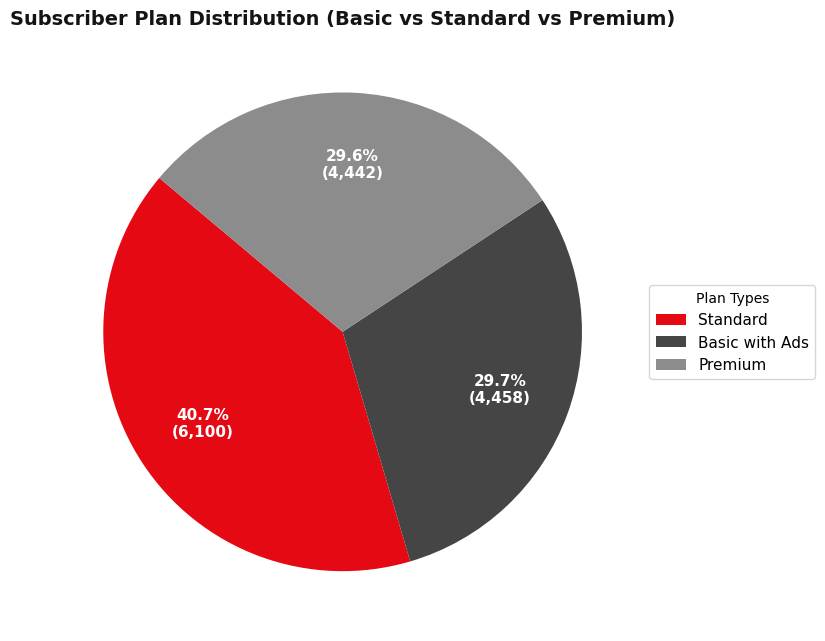

In [26]:
plt.figure(figsize=(8, 8))
plan_colors = ['#E50914', '#454545', '#8C8C8C']

def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n({val:,})'
    return my_autopct

plt.pie(
    subscriber_counts, 
    labels=None, 
    autopct=make_autopct(subscriber_counts), 
    startangle=140, 
    colors=plan_colors,
    pctdistance=0.7,
    textprops={'color': 'white', 'weight': 'bold', 'fontsize': 11}
)

plt.title('Subscriber Plan Distribution (Basic vs Standard vs Premium)', fontsize=14, fontweight='bold', color='#141414')

plt.legend(
    labels=subscriber_counts.index, 
    loc="center left", 
    bbox_to_anchor=(1, 0.5), 
    fontsize=11,
    title="Plan Types"
)

plt.tight_layout()
plt.savefig('Phase2_Chart6_SubscriberPlan_Final.png', dpi=300, bbox_inches='tight')
plt.show()

### **•	Device usage — a bar chart showing which devices people watch on most.**

In [27]:
most_watch_device = df_watch_history.groupby('device')['Hour'].sum().sort_values(ascending=False)

In [28]:
device_usage = most_watch_device.sort_values(ascending=True)
print(device_usage)

device
Streaming Stick    2.013239e+05
Game Console       2.700856e+05
Tablet             3.314516e+05
Laptop             4.966748e+05
Mobile             9.005267e+05
Smart TV           1.133405e+06
Name: Hour, dtype: float64


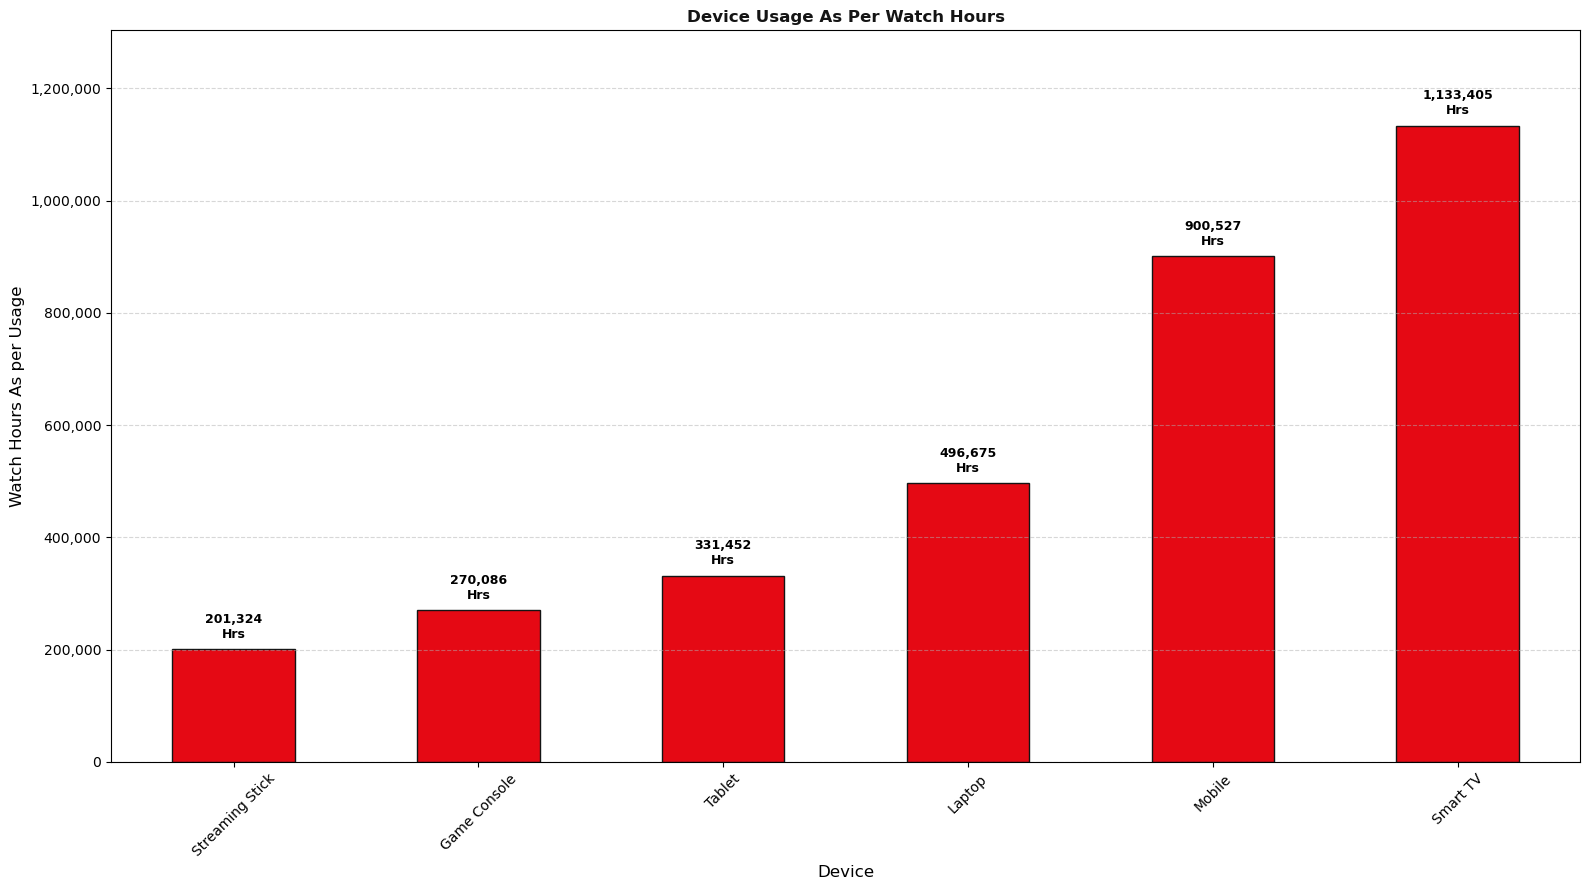

In [29]:
import matplotlib.ticker as ticker
plt.figure(figsize=(16,9))
device_usage.plot(kind='bar',color='#E50914',edgecolor='#141414')
plt.title('Device Usage As Per Watch Hours',fontsize=12,fontweight='bold',color='#141414')
plt.xlabel('Device',fontsize=12)
plt.ylabel('Watch Hours As per Usage',fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y',linestyle='--',alpha=0.5)
ax=plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,p: format(int(x),',')))
for index, value in enumerate(device_usage):
    rounded_value = int(round(value))
    plt.text(index, value + 15000, f'{rounded_value:,}\nHrs', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.ylim(0, max(device_usage) * 1.15)

plt.tight_layout()
plt.savefig('Phase2_Chart7_Bhagyashri.png',dpi=300,bbox_inches= 'tight')
plt.show()

### **•	Age distribution of subscribers — a histogram. Which age group watches most?**

In [30]:
age_bins = pd.cut(df_subscribers['age'],bins=[20,30,40,50,60,70,80])
age_group_counts = df_subscribers.groupby(age_bins)['age'].count()

C:\Users\Bhagyashri\AppData\Local\Temp\ipykernel_14764\2032979505.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_counts = df_subscribers.groupby(age_bins)['age'].count()


In [31]:
print("Total Subscribers by Age Group:")
print(age_group_counts)

Total Subscribers by Age Group:
age
(20, 30]    3407
(30, 40]    4470
(40, 50]    3375
(50, 60]    1438
(60, 70]     366
(70, 80]      41
Name: age, dtype: int64


In [32]:
most_active_age = age_group_counts.idxmax()
print(f"\nMost Active Age Group: {most_active_age}")


Most Active Age Group: (30, 40]


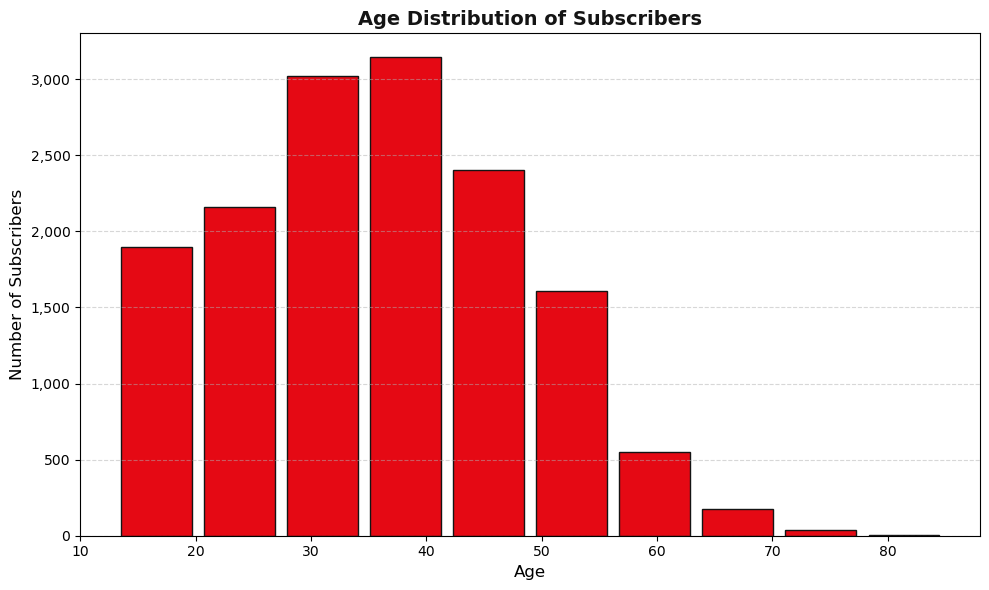

In [33]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(10, 6))
streamflix_red = '#E50914'

df_subscribers['age'].plot(kind='hist', bins=10, color=streamflix_red, edgecolor='#141414', rwidth=0.85)

plt.title('Age Distribution of Subscribers', fontsize=14, fontweight='bold', color='#141414')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of Subscribers', fontsize=12)

ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('Phase2_Chart8_AgeDistribution_Final.png', dpi=300, bbox_inches='tight')
plt.show()

### **•	Completion rate by genre — a bar chart. Which genres get finished?**

In [38]:
genre_completion = merge_dataset.groupby('primary_genre')['completed'].mean().sort_values(ascending=False) * 100

In [40]:
formatted_completion = genre_completion.map("{:.2f}%".format)
print("Completion Rate by Genre (Formatted):")
print(formatted_completion)

Completion Rate by Genre (Formatted):
primary_genre
Stand-Up         16.66%
Animation        16.47%
Musical          16.34%
Fantasy          16.33%
Sci-Fi           15.95%
Kids & Family    15.38%
Crime            15.38%
Mystery          15.24%
Comedy           15.16%
Thriller         15.13%
Drama            15.09%
Horror           15.09%
Romance          15.08%
Documentary      14.95%
Reality          14.93%
Action           14.92%
Name: completed, dtype: object


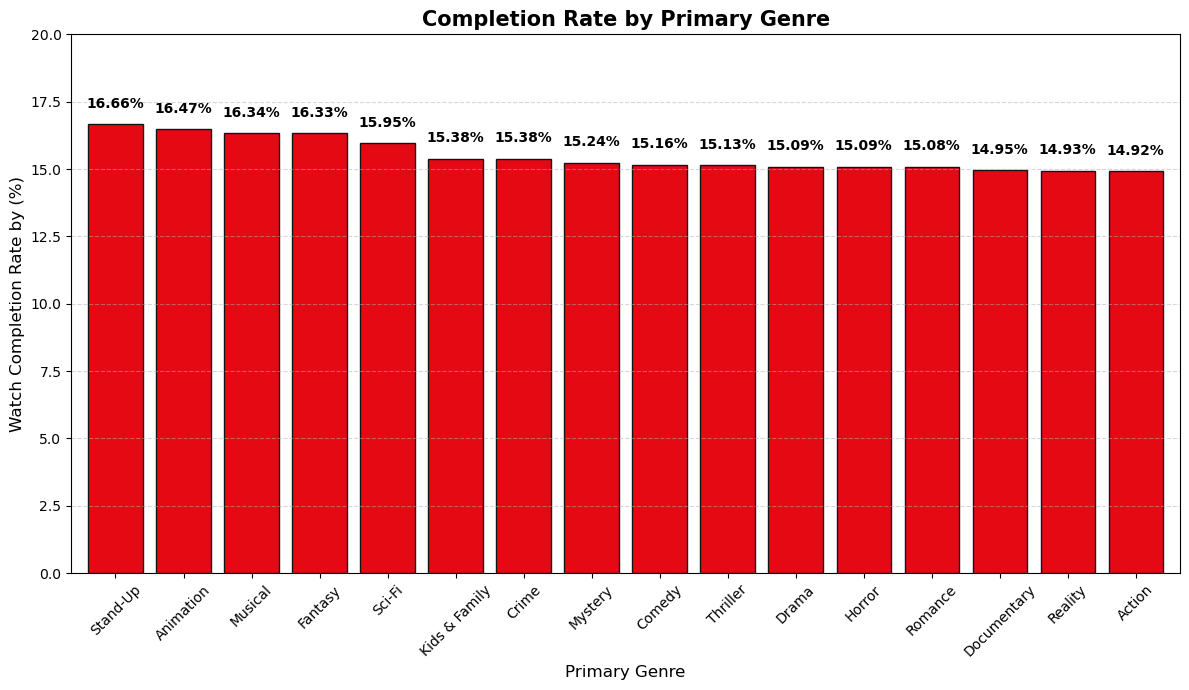

In [55]:
plt.figure(figsize=(12,7))
genre_completion.plot(kind='bar',color=streamflix_red, edgecolor='#141414', width=0.8)
plt.title('Completion Rate by Primary Genre',fontsize=15,fontweight='bold')
plt.xlabel('Primary Genre', fontsize=12)
plt.ylabel('Watch Completion Rate by (%)', fontsize=12)
plt.xticks(rotation=45)
for index, value in enumerate(genre_completion):
    plt.text(index, value + 0.5, f'{value:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.ylim(0, 20)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('Phase2_Chart9_GenreCompletion_Final.png', dpi=300, bbox_inches='tight')
plt.show()

### **•	Review sentiment breakdown — a bar chart of Positive / Neutral / Negative review counts.**

In [56]:
df_reviews = pd.read_csv(r"C:\Users\Bhagyashri\Downloads\ff5a102e4361911d42cef9e21cda23d0\reviews.csv")

In [66]:
Reviews_count = df_reviews.groupby('sentiment').size()

In [67]:
print(Reviews_count)

sentiment
Negative    12234
Neutral     22759
Positive    75007
dtype: int64


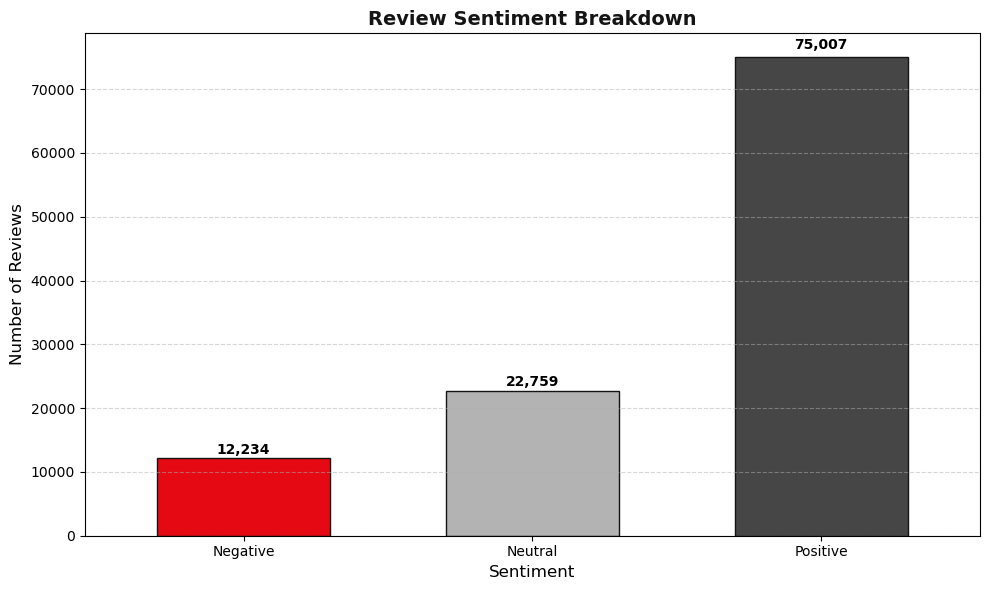

In [72]:
plt.figure(figsize=(10, 6))
sentiment_colors = ['#E50914', '#B3B3B3', '#464646']
Reviews_count.plot(kind='bar', color=sentiment_colors, edgecolor='#141414', width=0.6)

plt.title('Review Sentiment Breakdown', fontsize=14, fontweight='bold', color='#141414')
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.xticks(rotation=0) 

for index, value in enumerate(Reviews_count):
    plt.text(index, value + (value * 0.01), f'{value:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('Phase2_Chart10_SentimentBreakdown_Bhagyashri.png', dpi=300, bbox_inches='tight')

plt.show()